<a href="https://colab.research.google.com/github/Innovatewithapple/RNNProjects/blob/main/SentimentMentalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1886da0bed61537ad1ce98e9d6c2ce1985d3637568a7ac860986ea97230d0d16
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [68]:
import os
from google.colab import userdata
import tensorflow as tf
from tensorflow.keras.layers import Dense,Embedding,TextVectorization,Dropout,LSTM,Bidirectional,Input,SpatialDropout1D
from tensorflow.keras import Sequential
from lime.lime_text import LimeTextExplainer

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from collections import Counter

In [3]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
print('activated')

activated


In [4]:
!kaggle datasets download -d suchintikasarkar/sentiment-analysis-for-mental-health

Dataset URL: https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health
License(s): DbCL-1.0
100% 11.1M/11.1M [00:00<00:00, 13.7MB/s]



In [5]:
!unzip -q sentiment-analysis-for-mental-health.zip -d ./dataset_folder

In [6]:
df = pd.read_csv('/content/dataset_folder/Combined Data.csv')
df.sample(5)

,Unnamed: 0,statement,status
2064,2064,"My brother, Sonu, is the new owner",Normal
13839,13839,Every time I think about how much of a patheti...,Suicidal
32957,32957,"yes, i think he did.",Normal
18898,18898,"2020 was hell. At this point, it is just an ag...",Depression
6419,6419,Half an hour only discuss 1 proposal. Bismilla...,Normal


In [7]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
statement,362
status,0


In [9]:
#EDA Starts............
train_data = df.dropna(subset=['statement']).copy()
train_data.isnull().sum()

,0
Unnamed: 0,0
statement,0
status,0


In [10]:
train_data = train_data[train_data['statement'].str.strip() != ""]

In [11]:
statement_text = train_data['statement'].astype(str).values
status_text = train_data['status'].astype(str).values

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [12]:
#Label encoding
label_encoder = LabelEncoder()
status_text_encoded = label_encoder.fit_transform(status_text)

In [13]:
print(label_encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [14]:
x_train,x_test,y_train,y_test = train_test_split(statement_text,status_text_encoded,test_size=0.3,random_state=42,stratify=status_text_encoded)

In [15]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(32)

In [16]:
text_slicing = [len(sliceText.split()) for sliceText in statement_text]
averagetextlen = np.mean(text_slicing)
percentagetext = np.percentile(text_slicing,95)
maxtext = np.max(text_slicing)
print(averagetextlen)
print(percentagetext)
print(maxtext)

113.15872895351265
395.0
6300


In [59]:
# 1. Count every word
word_counts = Counter(" ".join(statement_text).split())

# 2. See how many words appear more than 5 times
useful_words = [word for word, count in word_counts.items() if count > 5]

print(f"Total Unique: {len(word_counts)}")
print(f"Words appearing > 5 times: {len(useful_words)}")

Total Unique: 154767
Words appearing > 5 times: 23991


In [60]:
max_words = 10000
max_len = 450

vector_layer = TextVectorization(max_tokens=max_words,output_mode='int',output_sequence_length=max_len)

In [61]:
vector_layer.adapt(statement_text)

In [62]:
model = Sequential([
    Input(shape=(1,),dtype=tf.string),
    vector_layer,

    Embedding(input_dim=max_words,output_dim=128),

    SpatialDropout1D(0.5),

    Bidirectional(LSTM(128,dropout=0.4,return_sequences=True)),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.4)),

    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(7,activation='softmax')
])

In [63]:
callback = EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True,verbose=1)

In [64]:
print(train_data['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [65]:
print(list(enumerate(label_encoder.classes_)))

[(0, 'Anxiety'), (1, 'Bipolar'), (2, 'Depression'), (3, 'Normal'), (4, 'Personality disorder'), (5, 'Stress'), (6, 'Suicidal')]


In [66]:
weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(train_data['status']),y=train_data['status'])

class_weight_dict = dict(enumerate(weights))
class_weight_dict

{0: np.float64(1.9593483839773869),
 1: np.float64(2.710067390297855),
 2: np.float64(0.48856512223170234),
 3: np.float64(0.4604942264490695),
 4: np.float64(6.987796790025202),
 5: np.float64(2.909105969407477),
 6: np.float64(0.7065205729306367)}

In [67]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(train_ds,validation_data=val_ds,epochs=15,class_weight=class_weight_dict,verbose=1,callbacks=[callback])

Epoch 1/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 98s 82ms/step - accuracy: 0.5029 - loss: 1.4449 - val_accuracy: 0.5506 - val_loss: 0.9665
Epoch 2/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 94s 81ms/step - accuracy: 0.5811 - loss: 1.0833 - val_accuracy: 0.6273 - val_loss: 0.8318
Epoch 3/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 93s 80ms/step - accuracy: 0.6238 - loss: 0.8935 - val_accuracy: 0.6281 - val_loss: 0.7740
Epoch 4/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 93s 81ms/step - accuracy: 0.6516 - loss: 0.7704 - val_accuracy: 0.6477 - val_loss: 0.8124
Epoch 5/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 93s 81ms/step - accuracy: 0.6734 - loss: 0.6870 - val_accuracy: 0.6592 - val_loss: 0.7588
Epoch 6/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 142s 81ms/step - accuracy: 0.6832 - loss: 0.6413 - val_accuracy: 0.6802 - val_loss: 0.6983
Epoch 7/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 142s 81ms/step - accuracy: 0.7050 - loss: 0.5772 - val_accuracy: 0.7132 - val_loss: 0.7090
Epoch 8/15
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 92s 80ms/step - accuracy: 0.7239

494/494 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step
📊 CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

             Anxiety       0.82      0.80      0.81      1152
             Bipolar       0.77      0.81      0.79       833
          Depression       0.82      0.50      0.62      4622
              Normal       0.94      0.89      0.92      4903
Personality disorder       0.38      0.80      0.51       323
              Stress       0.52      0.69      0.60       776
            Suicidal       0.58      0.83      0.68      3196

            accuracy                           0.74     15805
           macro avg       0.69      0.76      0.70     15805
        weighted avg       0.78      0.74      0.74     15805



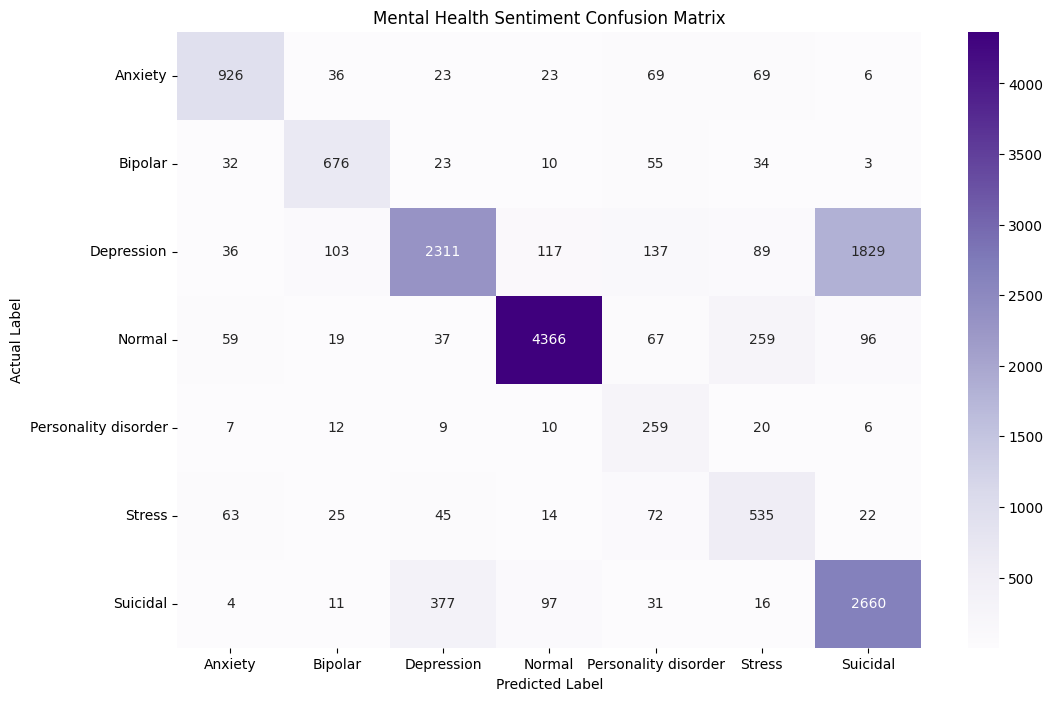

In [69]:
# 1. Get the model's raw predictions (Decimals/Probabilities)
y_pred_probs = model.predict(val_ds)

# 2. Convert probabilities to the Class ID (0, 1, 2, 3, 4, 5, 6)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Get the actual "True" labels from your validation pipe
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 4. PRINT THE TRUTH
# This shows Precision, Recall, and F1-Score for EVERY class
print("📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# 5. VISUALIZE THE CONFUSION
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Mental Health Sentiment Confusion Matrix')
plt.show()